In [1]:
!pip install anthropic

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import os
os.environ["ANTHROPIC_API_KEY"] = "enter_key_here"

In [3]:
from anthropic import Anthropic
import os

client = Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])
print("Client created successfully")

Client created successfully


In [4]:
from anthropic import Anthropic
import os

client = Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])

response = client.messages.create(
    model="claude-haiku-4-5",
    max_tokens=50,
    messages=[
        {"role": "user", "content": "Say hello in one sentence."}
    ]
)

print(response.content[0].text)

Hello! I'm happy to help you with whatever you need.


In [5]:
print(os.getcwd())
print(os.listdir())
print(os.path.exists("HelpHerInvest/Data/final_dataset_20260224v2.csv.zip"))

/home/jupyter-anjv/HelpHerInvest/Playground/Week 08 Develop 3rd modeling approach (even more complex)/Jenice Playground
['jenice playground', '.ipynb_checkpoints', 'week08_claude_api.ipynb']
False


In [6]:
import os
print(os.path.exists("../../../Data/final_dataset_20260224v2.csv.zip"))

True


In [7]:
import pandas as pd
import zipfile

zip_path = "../../../Data/final_dataset_20260224v2.csv.zip"

with zipfile.ZipFile(zip_path) as z:
    df = pd.read_csv(z.open("final_dataset_20260224v2.csv"))

print(df.shape)
df.head()

(302024, 18)


,Date,Ticker,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_ex_1m,rel_3m_spy,rel_6m_spy,rel_12m_spy,vol_3m,vol_6m,drawdown_6m,drawdown_12m,pct_above_200dma,adj_close,fwd_excess,fwd_return
0,2010-02-28,NVDA,0.1635,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3713,-0.1806,-0.1889
1,2010-02-28,GOOGL,-0.5752,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.0843,-0.0698,-0.0782
2,2010-02-28,AAPL,0.3245,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.1310,0.2637,0.2554
3,2010-02-28,MSFT,-0.2211,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.4773,-0.0877,-0.0960
4,2010-02-28,AMZN,-1.2056,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.9200,0.0679,0.0596


In [8]:
import pandas as pd
import numpy as np

df["Date"] = pd.to_datetime(df["Date"])

def time_split(df, date_col="Date", train_frac=0.7, val_frac=0.15):
    df = df.sort_values(date_col).copy()
    unique_dates = df[date_col].drop_duplicates().sort_values().to_numpy()

    n = len(unique_dates)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))

    train_dates = unique_dates[:train_end]
    val_dates = unique_dates[train_end:val_end]
    test_dates = unique_dates[val_end:]

    training_data = df[df[date_col].isin(train_dates)]
    validation_data = df[df[date_col].isin(val_dates)]
    testing_data = df[df[date_col].isin(test_dates)]

    return training_data, validation_data, testing_data

training_data, validation_data, testing_data = time_split(df)

print("Train size:", training_data.shape)
print("Validation size:", validation_data.shape)
print("Test size:", testing_data.shape)

Train size: (193638, 18)
Validation size: (52704, 18)
Test size: (55682, 18)


In [9]:
def preprocess_data(df):
    df_dropped = df.dropna().copy()
    df_dropped["log_adj_close"] = np.log(df_dropped["adj_close"])
    return df_dropped

train_df = preprocess_data(training_data)
val_df = preprocess_data(validation_data)
test_df = preprocess_data(testing_data)

print("Processed train:", train_df.shape)
print("Processed val:", val_df.shape)
print("Processed test:", test_df.shape)

Processed train: (175057, 19)
Processed val: (50961, 19)
Processed test: (48493, 19)


In [10]:
#Grabbing one row from val_df
row = val_df.iloc[0]
print(row)

Date                2021-05-31 00:00:00
Ticker                             SITE
mom_1m                          -0.6464
mom_3m                           -0.077
mom_6m                           -0.086
mom_12m                         -0.0469
mom_12m_ex_1m                   -0.0277
rel_3m_spy                       -0.077
rel_6m_spy                       -0.086
rel_12m_spy                     -0.0469
vol_3m                           0.2931
vol_6m                           0.1085
drawdown_6m                      0.1177
drawdown_12m                     0.1482
pct_above_200dma                -0.2446
adj_close                        172.04
fwd_excess                       0.0845
fwd_return                       0.1631
log_adj_close                  5.147727
Name: 194796, dtype: object


In [11]:
print(val_df.columns)

Index(['Date', 'Ticker', 'mom_1m', 'mom_3m', 'mom_6m', 'mom_12m',
       'mom_12m_ex_1m', 'rel_3m_spy', 'rel_6m_spy', 'rel_12m_spy', 'vol_3m',
       'vol_6m', 'drawdown_6m', 'drawdown_12m', 'pct_above_200dma',
       'adj_close', 'fwd_excess', 'fwd_return', 'log_adj_close'],
      dtype='object')


In [12]:
prompt = f"""
You are predicting whether a stock will outperform the S&P 500.

Here are the stock's financial features:
- 1-month momentum: {row['mom_1m']}
- 3-month momentum: {row['mom_3m']}
- 6-month momentum: {row['mom_6m']}
- 12-month momentum: {row['mom_12m']}
- relative strength (3m vs S&P): {row['rel_3m_spy']}
- relative strength (6m vs S&P): {row['rel_6m_spy']}
- volatility (3m): {row['vol_3m']}
- drawdown (6m): {row['drawdown_6m']}
- % above 200 day moving average: {row['pct_above_200dma']}

Respond with ONLY:
0 = underperform
1 = outperform
"""

In [13]:
#sending to Claude
response = client.messages.create(
    model="claude-haiku-4-5",
    max_tokens=10,
    messages=[
        {"role": "user", "content": prompt}
    ]
)

prediction = response.content[0].text.strip()
print("Prediction:", prediction)

Prediction: 0


In [14]:
#now running on a small sample of the validation set

In [15]:
val_df = val_df.copy()
val_df["y_true"] = (val_df["fwd_excess"] > 0).astype(int)

val_sample = val_df.sample(20, random_state=42).copy()
print(val_sample[["Ticker", "fwd_excess", "y_true"]].head())

       Ticker  fwd_excess  y_true
210565  JCYGY      0.4021       1
208988    IDA      0.0423       1
226010    PFS      0.0006       1
213820    CNP      0.0366       1
242531   SFNC     -0.2047       0


In [16]:
#prediction function
def claude_predict_row(row, client):
    prompt = f"""
You are predicting whether a stock will outperform the S&P 500.

Here are the stock's financial features:
- 1-month momentum: {row['mom_1m']}
- 3-month momentum: {row['mom_3m']}
- 6-month momentum: {row['mom_6m']}
- 12-month momentum: {row['mom_12m']}
- relative strength (3m vs S&P): {row['rel_3m_spy']}
- relative strength (6m vs S&P): {row['rel_6m_spy']}
- volatility (3m): {row['vol_3m']}
- drawdown (6m): {row['drawdown_6m']}
- % above 200 day moving average: {row['pct_above_200dma']}

Respond with ONLY:
0 = underperform
1 = outperform
"""
    response = client.messages.create(
        model="claude-haiku-4-5",
        max_tokens=10,
        messages=[{"role": "user", "content": prompt}]
    )
    text = response.content[0].text.strip()
    return 1 if text == "1" else 0

In [17]:
#running predictions on the sample
val_sample["y_pred"] = val_sample.apply(lambda row: claude_predict_row(row, client), axis=1)
val_sample[["Ticker", "y_true", "y_pred"]].head(10)

,Ticker,y_true,y_pred
210565,JCYGY,1,1
208988,IDA,1,1
226010,PFS,1,1
213820,CNP,1,1
242531,SFNC,0,0
235239,RXRX,1,0
226942,AFG,0,0
222286,SXI,1,0
220037,GNTX,1,0
245362,SCI,1,0


In [18]:
#Model performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_true = val_sample["y_true"]
y_pred = val_sample["y_pred"]

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))

Accuracy: 0.4
Precision: 0.6666666666666666
Recall: 0.2857142857142857
F1 Score: 0.4


In [19]:
#Variation 2 (improved prompt)
def claude_predict_row_v2(row, client):
    prompt = f"""
You are predicting whether a stock will outperform the S&P 500.

General guidance:
- Strong positive momentum and strong relative strength indicate likely outperformance.
- High volatility and large drawdowns indicate risk and possible underperformance.
- Stocks above their 200-day moving average are generally stronger.

Here are the stock's financial features:
- 1-month momentum: {row['mom_1m']}
- 3-month momentum: {row['mom_3m']}
- 6-month momentum: {row['mom_6m']}
- 12-month momentum: {row['mom_12m']}
- relative strength (3m vs S&P): {row['rel_3m_spy']}
- relative strength (6m vs S&P): {row['rel_6m_spy']}
- volatility (3m): {row['vol_3m']}
- drawdown (6m): {row['drawdown_6m']}
- % above 200 day moving average: {row['pct_above_200dma']}

Respond with ONLY:
0 = underperform
1 = outperform
"""
    response = client.messages.create(
        model="claude-haiku-4-5",
        max_tokens=10,
        messages=[{"role": "user", "content": prompt}]
    )
    text = response.content[0].text.strip()
    return 1 if text == "1" else 0

In [20]:
val_sample["y_pred_v2"] = val_sample.apply(lambda row: claude_predict_row_v2(row, client), axis=1)

In [21]:
y_pred_v2 = val_sample["y_pred_v2"]

print("Accuracy:", accuracy_score(y_true, y_pred_v2))
print("Precision:", precision_score(y_true, y_pred_v2))
print("Recall:", recall_score(y_true, y_pred_v2))
print("F1 Score:", f1_score(y_true, y_pred_v2))

Accuracy: 0.3
Precision: 0.5
Recall: 0.07142857142857142
F1 Score: 0.125


In [22]:
#Variation 3
def claude_predict_row_v3(row, client):
    prompt = f"""
You are predicting whether a stock will outperform the S&P 500.

Here are some examples:

Example 1:
High momentum, strong relative strength, low drawdown → 1

Example 2:
Negative momentum, weak relative strength, high drawdown → 0

Now evaluate this stock:

- 1-month momentum: {row['mom_1m']}
- 3-month momentum: {row['mom_3m']}
- 6-month momentum: {row['mom_6m']}
- 12-month momentum: {row['mom_12m']}
- relative strength (3m vs S&P): {row['rel_3m_spy']}
- relative strength (6m vs S&P): {row['rel_6m_spy']}
- volatility (3m): {row['vol_3m']}
- drawdown (6m): {row['drawdown_6m']}
- % above 200 day moving average: {row['pct_above_200dma']}

Respond with ONLY:
0 = underperform
1 = outperform
"""
    response = client.messages.create(
        model="claude-haiku-4-5",
        max_tokens=10,
        messages=[{"role": "user", "content": prompt}]
    )
    text = response.content[0].text.strip()
    return 1 if text == "1" else 0

In [23]:
val_sample["y_pred_v3"] = val_sample.apply(lambda row: claude_predict_row_v3(row, client), axis=1)

In [24]:
y_pred_v3 = val_sample["y_pred_v3"]

print("Accuracy:", accuracy_score(y_true, y_pred_v3))
print("Precision:", precision_score(y_true, y_pred_v3))
print("Recall:", recall_score(y_true, y_pred_v3))
print("F1 Score:", f1_score(y_true, y_pred_v3))

Accuracy: 0.25
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


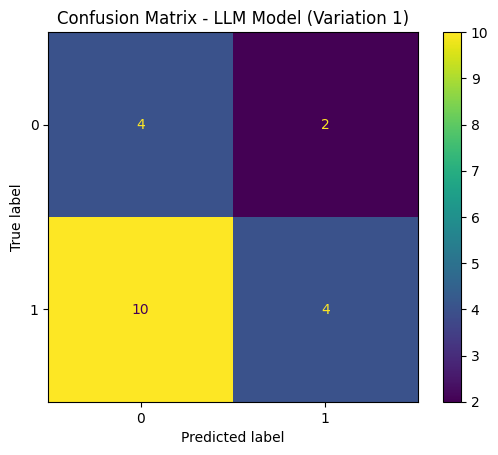

In [25]:
#Variation 1 Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(val_sample["y_true"], val_sample["y_pred"])

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - LLM Model (Variation 1)")
plt.show()